In [1]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded model: gpt2


In [3]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [5]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [6]:
from compute_perplexity_dims import compute_p1, compute_p2, compute_p3
from utils import swap_speaker_tokens_with_metadata, get_shuffled_dialog_data, reorder_tokens

[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
import numpy as np
import re
import pandas as pd

In [118]:
tri_pilot_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/triadic-pilot/conversations.csv")
tri_pilot_df

,file_name,file_content
0,p08_s03,<SPK1> Oh. Yay. It's story time. <SPK2> Hello....
1,p10_s02,<SPK3> Hello. <SPK2> Hi. <SPK0> Hi. <SPK3> You...
2,p09_s04,<SPK2> I will now turn on a start audio video ...
3,p09_s05,"<SPK0> Uh, and how did they turned on? <SPK3> ..."
4,p12_s02,<SPK2> Hello. <SPK1> Hello. <SPK0> Hello. <SPK...
...,...,...
67,p03_s05,<SPK2> [Foreign Language 00:00:57] <SPK1> [For...
68,p11_s05,<SPK0> (laughs) So funny. <SPK2> Hello. <SPK1>...
69,p12_s00,"<SPK2> Hello. <SPK1> Hi. Hi, Jibo. <SPK0> Hi, ..."
70,p10_s00,<SPK2> Hello. I am now on story time mode. My ...


In [119]:
dialog = tri_pilot_df.iloc[0]['file_content']
file_name = tri_pilot_df.iloc[0]['file_name']

In [260]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

In [261]:
assert len(matches) == len(dialog_lines)

In [262]:
p1_triadic = compute_p1(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

 94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████        | 7321/7821 [03:31<00:14, 34.69it/s]


In [263]:
p2_triadic = compute_p2(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

 94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████        | 7321/7821 [03:37<00:14, 33.65it/s]


In [264]:
p3_triadic = compute_p3(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

 94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████        | 7321/7821 [03:38<00:14, 33.52it/s]


In [265]:
from utils import correlation_heatmap

In [266]:
# AFTER
all_data_pca = pd.DataFrame({"P1": p1_triadic, "P2": p2_triadic, "P3":p3_triadic})
col_1 = ["P1","P2","P3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_pca)

In [267]:
all_data = pd.DataFrame({'p1_triadic':p1_triadic, 'p2_triadic':p2_triadic, 'p3_triadic':p3_triadic})

In [268]:
from sklearn.decomposition import PCA

P1_pca = all_data['p1_triadic'].bfill().to_numpy()
P2_pca = all_data['p2_triadic'].bfill().to_numpy()
P3_pca = all_data['p3_triadic'].bfill().to_numpy()

X = np.column_stack([P2_pca, P3_pca])
pca = PCA(n_components=2)
X_orthogonal = pca.fit_transform(X)

In [269]:
# AFTER
all_data_pca = pd.DataFrame({"P2_pca": P2_pca, "P3_pca":P3_pca})
col_1 = ["P2_pca","P3_pca"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_pca)

In [270]:
fig_corr

In [271]:
fig_r

In [272]:
file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
data_full = pd.DataFrame({'p1':p1_triadic, 'p2':p2_triadic, 'p3':p3_triadic, 'p2_pca':P2_pca, 'P3_pca':P3_pca}).to_csv(file_name_sample, index=False)

### Annotations

In [273]:
annotation_file = f"/u/sebono/conversational_dominance/data/processed/triadic-pilot/annotation_files/childs-joint-engagement-with-parent/aggregated_annotation_files.csv"

In [274]:
annotations = pd.read_csv(annotation_file)
annotations_dataset = annotations[annotations['uniq_vid_clip'].str.startswith(file_name)]
annotations_dataset.head()

,Unnamed: 0,Label-Name,NAN,Start-Timestamp,Start-Timestamp(sec),End-Timestamp,End-Timestamp(sec),Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
9256,0,p08-child (joint-engagement-wt-parent),NaN,00:00:00.000,0.0,00:00:05.000,5.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-0.0,NaN,NaN
9257,1,p08-child (joint-engagement-wt-parent),NaN,00:00:05.000,5.0,00:00:10.000,10.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-5.0,NaN,NaN
9258,2,p08-child (joint-engagement-wt-parent),NaN,00:00:10.000,10.0,00:00:15.000,15.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-10.0,NaN,NaN
9259,3,p08-child (joint-engagement-wt-parent),NaN,00:00:15.000,15.0,00:00:20.000,20.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-15.0,NaN,NaN
9260,4,p08-child (joint-engagement-wt-parent),NaN,00:00:20.000,20.0,00:00:25.000,25.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-20.0,NaN,NaN


In [275]:
conversation_dataset_file = f'/u/sebono/conversational_dominance/data/external/triadic-pilot/{file_name}_REV.csv'
conversation_dataset = pd.read_csv(conversation_dataset_file)
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.
...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?"
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.


In [276]:
assert len(matches) == len(conversation_dataset['content'])

In [277]:
conversation_dataset["tokens"] = [token.detach().numpy() for token in token_list]
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content,tokens
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.,"[27, 4303, 42, 16, 29, 3966, 13, 575, 323, 13,..."
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.,"[27, 4303, 42, 17, 29, 18435, 13, 220]"
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.,"[27, 4303, 42, 16, 29, 15902, 13, 15902, 449, ..."
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...,"[27, 4303, 42, 17, 29, 314, 716, 407, 319, 836..."
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.,"[27, 4303, 42, 16, 29, 16805, 13, 220]"
...,...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...,"[27, 4303, 42, 17, 29, 843, 3387, 1844, 262, 1..."
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?","[27, 4303, 42, 16, 29, 1439, 826, 11, 345, 349..."
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.,"[27, 4303, 42, 17, 29, 6952, 345, 13, 47843, 3..."
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.,"[27, 4303, 42, 15, 29, 47843, 33847, 13, 220]"


In [278]:
import pandas as pd

df = conversation_dataset.copy()
df["start_time"] = pd.to_timedelta(df["timestamp"]).dt.total_seconds()
df["end_time"] = df["start_time"].shift(-1)
df.loc[df.index[-1], "end_time"] = df["start_time"].iloc[-1] + 1
df = df[["start_time", "end_time", "speaker", "content", "tokens"]]
df

,start_time,end_time,speaker,content,tokens
0,0.0,7.0,Parent,Oh. Yay. It's story time.,"[27, 4303, 42, 16, 29, 3966, 13, 575, 323, 13,..."
1,7.0,7.0,Robot,Hello.,"[27, 4303, 42, 17, 29, 18435, 13, 220]"
2,7.0,10.0,Parent,Hi. Hi Jibo.,"[27, 4303, 42, 16, 29, 15902, 13, 15902, 449, ..."
3,10.0,16.0,Robot,I am not on Story Time mode. My camera will no...,"[27, 4303, 42, 17, 29, 314, 716, 407, 319, 836..."
4,16.0,16.0,Parent,Okay.,"[27, 4303, 42, 16, 29, 16805, 13, 220]"
...,...,...,...,...,...
458,1715.0,1718.0,Robot,And please complete the story survey with your...,"[27, 4303, 42, 17, 29, 843, 3387, 1844, 262, 1..."
459,1718.0,1719.0,Parent,"All right, you ready to make your survey?","[27, 4303, 42, 16, 29, 1439, 826, 11, 345, 349..."
460,1719.0,1720.0,Robot,Thank you. Bye bye.,"[27, 4303, 42, 17, 29, 6952, 345, 13, 47843, 3..."
461,1720.0,1720.0,Child,Bye bye.,"[27, 4303, 42, 15, 29, 47843, 33847, 13, 220]"


In [279]:
import numpy as np
import pandas as pd
from collections import defaultdict

def assign_words_to_bins(df, bin_size=5.0):
    """
    Assigns words to time bins based on uniform spread over the utterance duration.
    Ensures all bins from time 0 to max stop are represented.

    Returns:
        pd.DataFrame: each bin with its start time, assigned words, and count.
    """
    bin_tok = defaultdict(list)
    bin_ppl = defaultdict(list)
    tok_len = 0
    
    for _, row in df.iterrows():
        start = row["start_time"]
        stop = row["end_time"]
        duration = stop - start

        if duration <= 0 or pd.isna(start) or pd.isna(stop):
            continue

        tokens = row["tokens"]
        n_tokens = len(tokens)
        
        if n_tokens == 0:
            continue

        # Compute per-word time positions assuming uniform spread
        tok_times = np.linspace(start, stop, n_tokens + 1)
        for i, tok in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor(tok_end / bin_size))

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[b].append(tok)
                bin_ppl[b].append(tok_len + i)

        tok_len += n_tokens
    # Determine full range of bins
    max_bin = int(np.ceil(df["end_time"].max() / bin_size))
    all_bins = list(range(max_bin + 1))

    # Construct DataFrame with all bins, filling empty ones with []
    bins_df = pd.DataFrame([
        {
            "time_bin": b,
            "start_time": b * bin_size,
            "end_time": (b + 1) * bin_size,
            "words": tokenizer.decode(torch.tensor(bin_tok[b]), skip_special_tokens=True),
            "ppl": bin_ppl[b],
            "n_tok": len(bin_tok[b])
        }
        for b in all_bins
    ])

    return bins_df

In [280]:
bins_df = assign_words_to_bins(df, bin_size=5.0)

In [281]:
bins_df

,time_bin,start_time,end_time,words,ppl,n_tok
0,0,0.0,5.0,<SPK1> Oh. Yay. It's,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
1,1,5.0,10.0,'s story time. <SPK1> Hi. Hi Jibo.,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...",17
2,2,10.0,15.0,<SPK2> I am not on Story Time mode. My camera...,"[27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 3...",24
3,3,15.0,20.0,and video recording. <SPK2> Let's get started...,"[50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 6...",17
4,4,20.0,25.0,we will be reading storybooks together. If yo...,"[66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 7...",16
...,...,...,...,...,...,...
341,341,1705.0,1710.0,<SPK2> I will now stop recording to respect y...,"[5824, 5825, 5826, 5827, 5828, 5829, 5830, 583...",26
342,342,1710.0,1715.0,<SPK0> Bye bye. <SPK2> I will switch back to...,"[5849, 5850, 5851, 5852, 5853, 5854, 5855, 585...",35
343,343,1715.0,1720.0,<SPK2> And please complete the story survey w...,"[5883, 5884, 5885, 5886, 5887, 5888, 5889, 589...",46
344,344,1720.0,1725.0,<SPK1> Bye bye...,"[5928, 5929, 5930, 5931, 5932, 5933, 5934, 593...",9


In [282]:
assert len(bins_df) == len(annotations_dataset)

In [283]:
combined_df = pd.concat([bins_df.reset_index(drop=True), annotations_dataset.iloc[:bins_df.shape[0]].reset_index(drop=True)], axis=1)
combined_df.iloc[15:]

,time_bin,start_time,end_time,words,ppl,n_tok,Unnamed: 0,Label-Name,NAN,Start-Timestamp,...,Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
15,15,75.0,80.0,the coconut tree.. <SPK2> Can you tell me,"[196, 197, 198, 199, 200, 201, 202, 203, 204, ...",15,15,p08-child (joint-engagement-wt-parent),NaN,00:01:15.000,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-75.0,1.0,0.000000
16,16,80.0,85.0,me what- <SPK1> Oh Jibo has a question. Jibo...,"[210, 211, 212, 213, 214, 215, 216, 217, 218, ...",38,16,p08-child (joint-engagement-wt-parent),NaN,00:01:20.000,...,00:00:05.000,5.0,1.0,Susanna/,0.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-80.0,0.5,0.707107
17,17,85.0,90.0,there are in the picture? <SPK1> What letters...,"[247, 248, 249, 250, 251, 252, 253, 254, 255, ...",49,17,p08-child (joint-engagement-wt-parent),NaN,00:01:25.000,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-85.0,1.0,0.000000
18,18,90.0,95.0,"<SPK1> B. <SPK1> C. Good job. A, B, C. <SPK2>...","[295, 296, 297, 298, 299, 300, 301, 302, 303, ...",36,18,p08-child (joint-engagement-wt-parent),NaN,00:01:30.000,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-90.0,1.0,0.000000
19,19,95.0,100.0,<SPK1> Awe thanks. Good job. Oh,"[330, 331, 332, 333, 334, 335, 336, 337, 338, ...",14,19,p08-child (joint-engagement-wt-parent),NaN,00:01:35.000,...,00:00:05.000,5.0,2.0,Susanna/,2.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-95.0,2.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,341,1705.0,1710.0,<SPK2> I will now stop recording to respect y...,"[5824, 5825, 5826, 5827, 5828, 5829, 5830, 583...",26,341,p08-child (joint-engagement-wt-parent),NaN,00:28:25.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1705.0,NaN,NaN
342,342,1710.0,1715.0,<SPK0> Bye bye. <SPK2> I will switch back to...,"[5849, 5850, 5851, 5852, 5853, 5854, 5855, 585...",35,342,p08-child (joint-engagement-wt-parent),NaN,00:28:30.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1710.0,NaN,NaN
343,343,1715.0,1720.0,<SPK2> And please complete the story survey w...,"[5883, 5884, 5885, 5886, 5887, 5888, 5889, 589...",46,343,p08-child (joint-engagement-wt-parent),NaN,00:28:35.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1715.0,NaN,NaN
344,344,1720.0,1725.0,<SPK1> Bye bye...,"[5928, 5929, 5930, 5931, 5932, 5933, 5934, 593...",9,344,p08-child (joint-engagement-wt-parent),NaN,00:28:40.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1720.0,NaN,NaN


In [284]:
import pandas as pd

def expand_multiple_ppl_by_token(bin_df, ppl_dict, annotation_cols=None):
    """
    Expands a bin-level DataFrame into token-level rows, adding multiple PPL values per token.

    Args:
        bin_df (pd.DataFrame): must contain 'ppl' as a list of token indices.
        ppl_dict (dict): dictionary of {name: List[float]}, e.g. {'ppl1': [...], 'ppl2': [...]}
        annotation_cols (List[str]): optional list of annotation columns to repeat per token.

    Returns:
        pd.DataFrame: one row per token with multiple ppl values and repeated annotations.
    """
    # Validate that all ppl lists have the same length
    lengths = [len(v) for v in ppl_dict.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All PPL arrays must have the same length.")

    records = []

    for _, row in bin_df.iterrows():
        token_ids = row["ppl"]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        for tok_id in token_ids:
            if tok_id >= lengths[0]:
                continue  # skip out-of-bounds

            record = {"token_id": tok_id}
            for name, ppl_values in ppl_dict.items():
                record[name] = ppl_values[tok_id]

            if annotation_cols:
                for col in annotation_cols:
                    record[col] = row.get(col, None)

            records.append(record)

    return pd.DataFrame(records)

In [285]:
cols = ['Rating_x', 'Rating_y','words']
ppl_dict = {'P2_pca': all_data_pca["P2_pca"], 'P3_pca': all_data_pca["P3_pca"]}
all_data = expand_multiple_ppl_by_token(combined_df, ppl_dict, cols)
all_data

,token_id,P2_pca,P3_pca,Rating_x,Rating_y,words
0,0,8.689340,5.679613,NaN,NaN,<SPK1> Oh. Yay. It's
1,1,8.689340,4.582078,NaN,NaN,<SPK1> Oh. Yay. It's
2,2,7.461735,3.234659,NaN,NaN,<SPK1> Oh. Yay. It's
3,3,6.564613,2.018494,NaN,NaN,<SPK1> Oh. Yay. It's
4,4,5.682234,1.711300,NaN,NaN,<SPK1> Oh. Yay. It's
...,...,...,...,...,...,...
6276,5932,0.552102,4.030623,NaN,NaN,<SPK1> Bye bye...
6277,5933,0.503537,2.814869,NaN,NaN,<SPK1> Bye bye...
6278,5934,0.929375,3.261166,NaN,NaN,<SPK1> Bye bye...
6279,5935,1.354068,3.019453,NaN,NaN,<SPK1> Bye bye...


In [286]:
all_data.dropna()

,token_id,P2_pca,P3_pca,Rating_x,Rating_y,words
163,153,1.334000,2.367013,0.0,0.0,Oh you wanna see who it's by? By
164,154,1.796528,3.196721,0.0,0.0,Oh you wanna see who it's by? By
165,155,1.680250,3.164287,0.0,0.0,Oh you wanna see who it's by? By
166,156,1.915068,3.497021,0.0,0.0,Oh you wanna see who it's by? By
167,157,1.887978,2.898243,0.0,0.0,Oh you wanna see who it's by? By
...,...,...,...,...,...,...
6136,5797,1.686070,2.639400,0.0,0.0,<SPK2> That was a great story. That's it for
6137,5798,1.612927,1.877460,0.0,0.0,<SPK2> That was a great story. That's it for
6138,5799,2.622127,3.180974,0.0,0.0,<SPK2> That was a great story. That's it for
6139,5800,2.386268,3.137131,0.0,0.0,<SPK2> That was a great story. That's it for


In [288]:
# AFTER
col_1 = ["P2_pca","P3_pca"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data)

In [289]:
fig_corr

In [290]:
fig_r

### Clusters

In [291]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



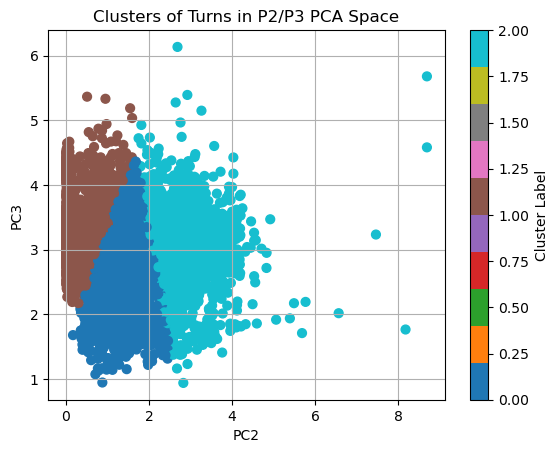

In [292]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [293]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0]
    for i in indices[:30]:  # first 5 turns
        print(dialog_lines[i])



--- Cluster 0 ---
<SPK1> C. Good job. A, B, C. 
<SPK0>  
<SPK1> A B to the top of the coconut tree.  Good job. What's next? 
<SPK0> A... 
<SPK1> Chicka, chicka, boom, boom- 
<SPK0>  Boom, boom.  
<SPK1> Here comes... 
<SPK0> H. 
<SPK2> How many letters are there now? 
<SPK1> How many letters? Can you count the letters? 
<SPK0> B. E. E. F. A. 
<SPK0> One, two, three, four, five. 
<SPK1> Brown. Yeah. A coconut's brown. TJ. Are you gonna pretend to eat me? I'm not a coconut. What color is a coconut inside? Do you know? 
<SPK0> Brown. 
<SPK1> Well the outside's brown but the inside's, let's ask Jibo. Hey Jibo do you know what color the inside of a coconut is? 
<SPK1> Have you seen what's inside a coconut before? 
<SPK0> It's white. 
<SPK1> Yeah it's white but have you seen it? 
<SPK0> No. 
<SPK1> I don't think so right? We've never seen, you've never seen a coconut have you? Can you sit down? Have you ever seen a coconut? No. No. 
<SPK0>  X. Y, X, Z. 
<SPK1> The whole alphabet up the... 
